In [1]:
!pip install -q -U transformers accelerate bitsandbytes sentencepiece datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 96.1 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 87.0 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have num

In [2]:
import torch
import transformers
import bitsandbytes as bnb

print("Torch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("BitsAndBytes:", bnb.__version__)

print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.10.0+cu128
Transformers: 5.12.0
BitsAndBytes: 0.49.2
CUDA: True
GPU: Tesla T4


In [4]:
# Fixed Parameters
EMOTIONS = ["desperate", "calm", "happy", "afraid", "angry"]
N_STORIES_PER_EMOTION = 60
N_NEUTRAL_TEXTS = 100
SWEEP_LAYERS = [8, 10, 13, 15, 17, 19, 21, 24, 26, 29]
D_MODEL = 4096
SKIP_FIRST_N_TOKENS = 50
PCA_VARIANCE_THRESHOLD = 0.50
POSITIVE_EMOTIONS = ["happy", "calm"]
NEGATIVE_EMOTIONS = ["desperate", "afraid", "angry"]

In [6]:
from pathlib import Path

print("Folders in /kaggle/input:")
for p in Path("/kaggle/input").iterdir():
    print(" ", p)

print("\nJSON files:")
for p in Path("/kaggle/input").rglob("*.jsonl"):
    print(" ", p)

Folders in /kaggle/input:
  /kaggle/input/datasets

JSON files:
  /kaggle/input/datasets/saksheee/emotion-stories1/neutral_texts.jsonl
  /kaggle/input/datasets/saksheee/emotion-stories1/emotion_stories.jsonl


In [7]:
#time to load the data in
import json

DATA_DIR = Path("/kaggle/input/datasets/saksheee/emotion-stories1")
emotion_stories = {e: [] for e in EMOTIONS}
with open(DATA_DIR / "emotion_stories.jsonl", "r") as f:
    for line in f:
        obj = json.loads(line.strip())
        emotion_stories[obj["emotion"]].append(obj["text"])

for e in EMOTIONS:
    assert len(emotion_stories[e]) == N_STORIES_PER_EMOTION, \
        f"{e}: expected {N_STORIES_PER_EMOTION}, got {len(emotion_stories[e])}"
    print(f"{e}: {len(emotion_stories[e])} stories")


neutral_texts = []
with open(DATA_DIR / "neutral_texts.jsonl", "r") as f:
    for line in f:
        obj = json.loads(line.strip())
        neutral_texts.append(obj["text"])
        
assert len(neutral_texts) == N_NEUTRAL_TEXTS, \
    f"Neutral: expected {N_NEUTRAL_TEXTS}, got {len(neutral_texts)}"
print(f"Neutral texts: {len(neutral_texts)}")

assert len(neutral_texts) == N_NEUTRAL_TEXTS, \
    f"Neutral: expected {N_NEUTRAL_TEXTS}, got {len(neutral_texts)}"
print(f"Neutral texts: {len(neutral_texts)}")


for e in EMOTIONS:
    print(f"\n[{e}] {emotion_stories[e][0][:120]}...")

desperate: 60 stories
calm: 60 stories
happy: 60 stories
afraid: 60 stories
angry: 60 stories
Neutral texts: 100
Neutral texts: 100

[desperate] Marcus stared at the email timestamp—he had forty minutes before the server wiped his three years of unrecovered code. H...

[calm] The server room caught fire during Marcus's overnight shift, smoke pouring through the vents while alarms screamed. He p...

[happy] Marcus burst through the office door screaming his promotion before anyone could ask. He sprinted around cubicles high-f...

[afraid] Marcus sat in the fluorescent-lit break room, leg bouncing under the table. In ten minutes he would be called into the c...

[angry] Marcus sat in the quarterly review, jaw tight, as his manager took credit for the project he had spent three months buil...


In [8]:
!pip uninstall -y transformers
!pip install transformers==4.52.4

Found existing installation: transformers 5.12.0
Uninstalling transformers-5.12.0:
  Successfully uninstalled transformers-5.12.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 80.2 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 98.0 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.10.1
    Uninstalling huggingface_hub-1.10.1:
      Successfully uninstalled huggingface_hub-1.10.1
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2


In [13]:
!pip uninstall -y keras keras-nlp keras-hub tensorflow tensorflow-text
!pip install -q --force-reinstall transformers==4.55.4

Found existing installation: keras 3.13.2
Uninstalling keras-3.13.2:
  Successfully uninstalled keras-3.13.2
Found existing installation: keras-nlp 0.26.0
Uninstalling keras-nlp-0.26.0:
  Successfully uninstalled keras-nlp-0.26.0
Found existing installation: keras-hub 0.26.0
Uninstalling keras-hub-0.26.0:
  Successfully uninstalled keras-hub-0.26.0
Found existing installation: tensorflow 2.19.0
Uninstalling tensorflow-2.19.0:
  Successfully uninstalled tensorflow-2.19.0
Found existing installation: tensorflow-text 2.19.0
Uninstalling tensorflow-text-2.19.0:
  Successfully uninstalled tensorflow-text-2.19.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 756.1 kB/s eta 0:00:00 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.7/58.7 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 95.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100

In [ ]:
import os
os.kill(os.getpid(), 9)

In [1]:
from transformers import AutoTokenizer

print("Transformers import works")

Transformers import works


In [2]:
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig
)
import torch

MODEL_ID = "nvidia/Mistral-NeMo-Minitron-8B-Base"

bnb_config = BitsAndBytesConfig(
    load_in_8bit=True,
)

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Loading model (8-bit)...")

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
)

print("\nArchitecture:")
print(f"  Layers: {model.config.num_hidden_layers}")
print(f"  Hidden dim: {model.config.hidden_size}")
print(f"  Vocab size: {model.config.vocab_size}")

if hasattr(model.config, "intermediate_size"):
    print(f"  Intermediate size: {model.config.intermediate_size}")

print(f"  lm_head shape: {tuple(model.lm_head.weight.shape)}")

# verify layer access for activation hooks
print("\nVerification:")
print("Layer container type:", type(model.model.layers))
print("Number of layers:", len(model.model.layers))

assert len(model.model.layers) == model.config.num_hidden_layers

vram = torch.cuda.memory_allocated() / 1e9
print(f"\nVRAM after load: {vram:.2f} GB")

print("\nModel Loaded Successfully")

Loading tokenizer...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/9.26M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

Loading model (8-bit)...


...

model-00002-of-00004.safetensors:   0%|          | 0.00/4.99G [00:00<?, ?B/s]

model-00001-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]


Architecture:
  Layers: 40
  Hidden dim: 4096
  Vocab size: 131072
  Intermediate size: 11520
  lm_head shape: (131072, 4096)

Verification:
Layer container type: <class 'torch.nn.modules.container.ModuleList'>
Number of layers: 40

VRAM after load: 3.66 GB

Model Loaded Successfully


In [8]:
print(model.config.num_hidden_layers)

40


In [6]:
from pathlib import Path
import json

EMOTIONS = [
    "desperate",
    "calm",
    "happy",
    "afraid",
    "angry"
]

DATA_DIR = Path("/kaggle/input/datasets/saksheee/emotion-stories1")

emotion_stories = {e: [] for e in EMOTIONS}

with open(DATA_DIR / "emotion_stories.jsonl", "r") as f:
    for line in f:
        obj = json.loads(line)
        emotion_stories[obj["emotion"]].append(obj["text"])

neutral_texts = []

with open(DATA_DIR / "neutral_texts.jsonl", "r") as f:
    for line in f:
        obj = json.loads(line)
        neutral_texts.append(obj["text"])

print("Loaded dataset")

for e in EMOTIONS:
    print(
        f"{e}:",
        len(emotion_stories[e]),
        "stories"
    )

print("neutral:", len(neutral_texts))

Loaded dataset
desperate: 60 stories
calm: 60 stories
happy: 60 stories
afraid: 60 stories
angry: 60 stories
neutral: 100


In [3]:
def extract_activation(text: str, layer_idx: int) -> torch.Tensor:

    tokens = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(model.device)

    seq_len = tokens["input_ids"].shape[1]

    captured = {}

    def hook_fn(module, module_input, module_output):

        if isinstance(module_output, tuple):
            captured["act"] = module_output[0].detach().float()
        else:
            captured["act"] = module_output.detach().float()

    handle = model.model.layers[layer_idx].register_forward_hook(hook_fn)

    with torch.no_grad():
        model(**tokens)

    handle.remove()

    activation = captured["act"]

    start = min(SKIP_FIRST_N_TOKENS, seq_len - 1)

    mean_act = activation[0, start:, :].mean(dim=0)

    return mean_act.cpu()

print("extract_activation reloaded successfully")

extract_activation reloaded successfully


In [9]:
# ============================================================
# MISTRAL-NEMO CONFIG
# ============================================================

SEED = 42

SKIP_FIRST_N_TOKENS = 50

EMOTIONS = [
    "desperate",
    "calm",
    "happy",
    "afraid",
    "angry",
]

POSITIVE_EMOTIONS = [
    "happy",
    "calm",
]

NEGATIVE_EMOTIONS = [
    "desperate",
    "afraid",
    "angry",
]

# 40-layer model
SWEEP_LAYERS = [
    6,
    10,
    14,
    18,
    22,
    26,
    30,
    34,
]

PCA_VARIANCE_THRESHOLD = 0.80

print("Layers:", model.config.num_hidden_layers)
print("SWEEP_LAYERS:", SWEEP_LAYERS)

Layers: 40
SWEEP_LAYERS: [6, 10, 14, 18, 22, 26, 30, 34]


In [10]:
test_act = extract_activation(
    emotion_stories["desperate"][0],
    SWEEP_LAYERS[0]
)

print(test_act.shape)
print(test_act.dtype)

torch.Size([4096])
torch.float32


In [15]:
from tqdm.auto import tqdm

In [16]:
#now we have to run our 400 stories through these layers from here 
OUTPUT_DIR = Path("/kaggle/working")
all_activations = {}
all_neutral_activations = {}

for layer_idx in tqdm(SWEEP_LAYERS, desc="Layer sweep"):
    emo_path = OUTPUT_DIR / f"activations_layer_{layer_idx}.pt"
    neu_path = OUTPUT_DIR / f"neutral_layer_{layer_idx}.pt"
    if emo_path.exists() and neu_path.exists():
        print(f" Layer {layer_idx}: checkpoint found, loading from disk (skipping extraction)")
        all_activations[layer_idx] = torch.load(emo_path)
        all_neutral_activations[layer_idx] = torch.load(neu_path)

    layer_acts = {}

    #emotional stories
    for emotion in EMOTIONS:
        stories = emotion_stories[emotion]
        acts = []
        for story in tqdm(stories, desc=f"  L{layer_idx}/{emotion}", leave=False):
            acts.append(extract_activation(story, layer_idx))
        layer_acts[emotion] = torch.stack(acts)
        print(f"  {emotion}: {layer_acts[emotion].shape}")
    #neutral texts
    neutral_acts = []
    for text in tqdm(neutral_texts, desc=f"  L{layer_idx}/neutral", leave=False):
        neutral_acts.append(extract_activation(text, layer_idx))
    neutral_tensor = torch.stack(neutral_acts)

    all_activations[layer_idx] = layer_acts
    all_neutral_activations[layer_idx] = neutral_tensor

    torch.save(layer_acts, emo_path)
    torch.save(neutral_tensor, neu_path)

    torch.cuda.memory_allocated() / 1e9
    print(f"  Layer {layer_idx} done. VRAM: {vram:1f} GB")
print("\nExtraction complete.")

Layer sweep:   0%|          | 0/8 [00:00<?, ?it/s]

  L6/desperate:   0%|          | 0/60 [00:00<?, ?it/s]

  desperate: torch.Size([60, 4096])


  L6/calm:   0%|          | 0/60 [00:00<?, ?it/s]

  calm: torch.Size([60, 4096])


...

  afraid: torch.Size([60, 4096])


  L34/angry:   0%|          | 0/60 [00:00<?, ?it/s]

  angry: torch.Size([60, 4096])


  L34/neutral:   0%|          | 0/100 [00:00<?, ?it/s]

  Layer 34 done. VRAM: 3.660804 GB

Extraction complete.


In [17]:
# Emotion vector = emotion mean - neutral mean

def compute_emotion_vectors(layer_acts, neutral_acts):
    """
    For each emotion:
    vector = mean(emotion_acts) - mean(neutral_acts)
    """

    emotion_means = {
        e: layer_acts[e].mean(dim=0)
        for e in EMOTIONS
    }

    neutral_mean = neutral_acts.mean(dim=0)

    return {
        e: emotion_means[e] - neutral_mean
        for e in EMOTIONS
    }


raw_vectors = {}

for layer_idx in SWEEP_LAYERS:
    raw_vectors[layer_idx] = compute_emotion_vectors(
        all_activations[layer_idx],
        all_neutral_activations[layer_idx]
    )

    print(f"Layer {layer_idx}: raw vectors computed")

Layer 6: raw vectors computed
Layer 10: raw vectors computed
Layer 14: raw vectors computed
Layer 18: raw vectors computed
Layer 22: raw vectors computed
Layer 26: raw vectors computed
Layer 30: raw vectors computed
Layer 34: raw vectors computed


In [21]:
import numpy as np

In [22]:
# PCA denoising using neutral activations

from sklearn.decomposition import PCA

def denoise_vectors(vectors, neutral_acts):
    """
    Project neutral PCA components out of each emotion vector.
    """

    pca = PCA()
    pca.fit(neutral_acts.numpy())

    cumvar = pca.explained_variance_ratio_.cumsum()

    k = int(np.searchsorted(cumvar, PCA_VARIANCE_THRESHOLD)) + 1

    print(
        f"PCA: {k} components explain {cumvar[k-1] * 100:.1f}% neutral variance"
    )

    U = torch.tensor(
        pca.components_[:k].T,
        dtype=torch.float32
    )

    return {
        e: v - U @ (U.T @ v)
        for e, v in vectors.items()
    }


denoised_vectors = {}

for layer_idx in SWEEP_LAYERS:

    print(f"\nLayer {layer_idx}")

    denoised_vectors[layer_idx] = denoise_vectors(
        raw_vectors[layer_idx],
        all_neutral_activations[layer_idx]
    )


normalized_vectors = {}

for layer_idx in SWEEP_LAYERS:

    normalized_vectors[layer_idx] = {}

    for emotion, vec in denoised_vectors[layer_idx].items():

        norm = vec.norm()

        if norm > 0:
            normalized_vectors[layer_idx][emotion] = vec / norm
        else:
            normalized_vectors[layer_idx][emotion] = vec

print("\nDenoising and normalization complete.")


Layer 6
PCA: 44 components explain 80.3% neutral variance

Layer 10
PCA: 42 components explain 80.2% neutral variance

Layer 14
PCA: 31 components explain 80.2% neutral variance

Layer 18
PCA: 36 components explain 80.1% neutral variance

Layer 22
PCA: 41 components explain 80.5% neutral variance

Layer 26
PCA: 42 components explain 80.4% neutral variance

Layer 30
PCA: 42 components explain 80.1% neutral variance

Layer 34
PCA: 44 components explain 80.4% neutral variance

Denoising and normalization complete.


Layer  6: valence separation = +0.8224
Layer 10: valence separation = +0.8187
Layer 14: valence separation = +0.8156
Layer 18: valence separation = +0.7890
Layer 22: valence separation = +0.7944
Layer 26: valence separation = +0.8119
Layer 30: valence separation = +0.8076
Layer 34: valence separation = +0.8096

>>> BEST PROBE LAYER: 18 (score: 0.7890)


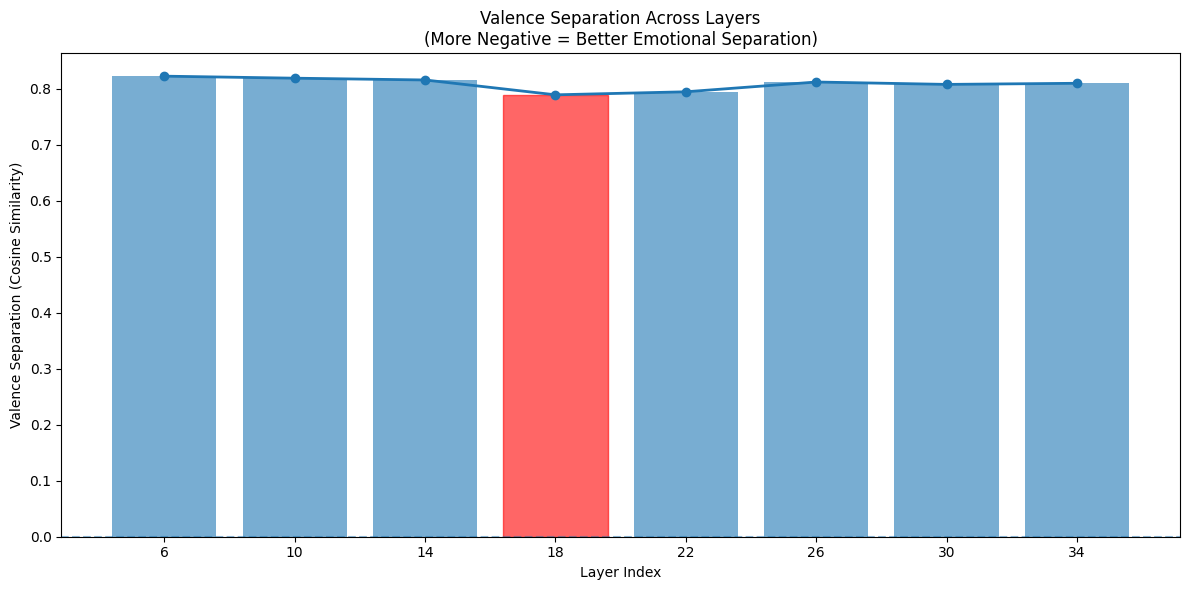

In [24]:
# now we will find the best layer out of these using cosine similarity
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.decomposition import PCA
import torch.nn.functional as F

def valence_separation(vectors):

    pos_mean = torch.stack(
        [vectors[e] for e in POSITIVE_EMOTIONS]
    ).mean(dim=0)

    neg_mean = torch.stack(
        [vectors[e] for e in NEGATIVE_EMOTIONS]
    ).mean(dim=0)

    return F.cosine_similarity(
        pos_mean.unsqueeze(0),
        neg_mean.unsqueeze(0),
        dim=1
    ).item()


layer_scores = {}

for layer_idx in SWEEP_LAYERS:

    score = valence_separation(
        normalized_vectors[layer_idx]
    )

    layer_scores[layer_idx] = score

    print(
        f"Layer {layer_idx:2d}: "
        f"valence separation = {score:+.4f}"
    )


best_layer = min(
    layer_scores,
    key=layer_scores.get
)

print(
    f"\n>>> BEST PROBE LAYER: "
    f"{best_layer} "
    f"(score: {layer_scores[best_layer]:.4f})"
)


layers_list = list(layer_scores.keys())
scores_list = [layer_scores[l] for l in layers_list]

plt.figure(figsize=(12, 6))

# Bar chart
bars = plt.bar(
    range(len(layers_list)),
    scores_list,
    alpha=0.6
)

# Highlight best layer
best_idx = layers_list.index(best_layer)
bars[best_idx].set_color("red")

# Line plot over bars
plt.plot(
    range(len(layers_list)),
    scores_list,
    marker="o",
    linewidth=2
)

plt.axhline(
    0,
    linestyle="--",
    alpha=0.5
)

plt.xticks(
    range(len(layers_list)),
    labels=layers_list
)

plt.xlabel("Layer Index")
plt.ylabel("Valence Separation (Cosine Similarity)")
plt.title(
    "Valence Separation Across Layers\n"
    "(More Negative = Better Emotional Separation)"
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "valence_separation.png",
    dpi=150
)

plt.show()

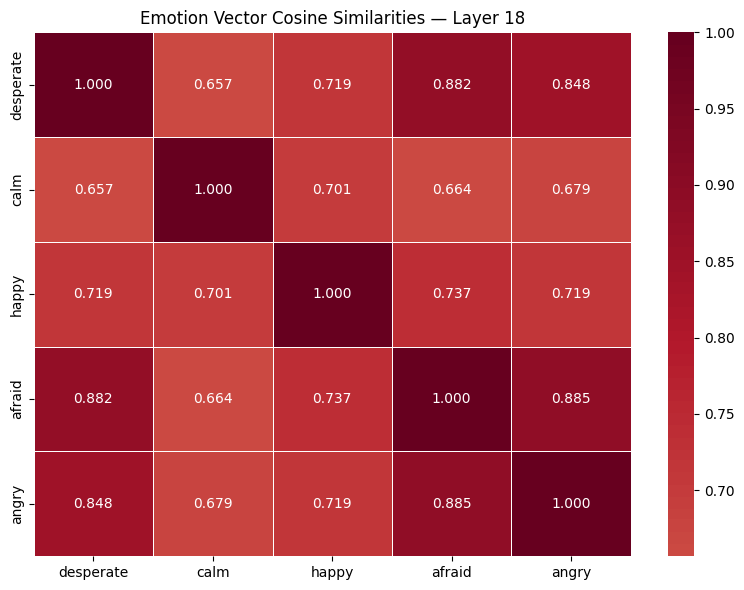

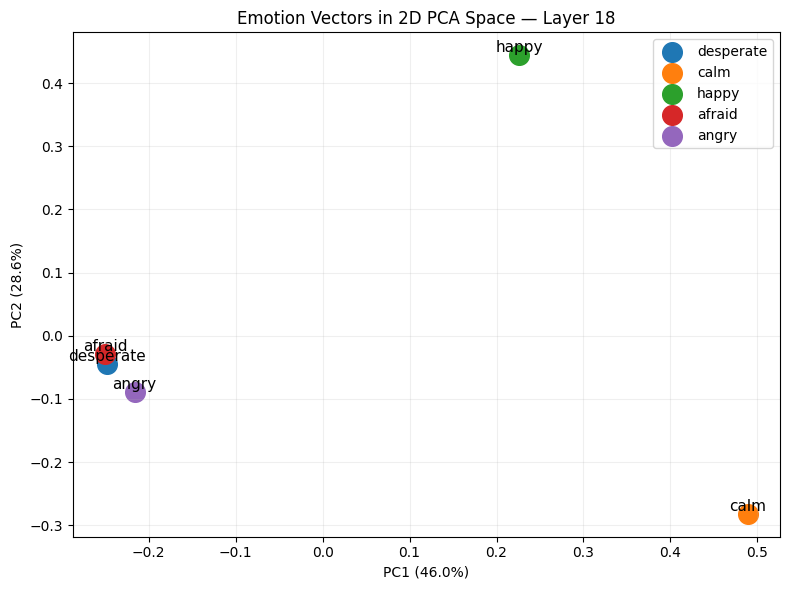

In [25]:
#let's visualize this data we can find stuff better 
vectors = normalized_vectors[best_layer]

# Cosine similarity matrix (5x5)
sim_matrix = torch.zeros((5, 5))
for i, e1 in enumerate(EMOTIONS):
    for j, e2 in enumerate(EMOTIONS):
        sim_matrix[i, j] = F.cosine_similarity(
            vectors[e1].unsqueeze(0), vectors[e2].unsqueeze(0)
        )

plt.figure(figsize=(8, 6))
sns.heatmap(sim_matrix.numpy(), annot=True, fmt=".3f", cmap="RdBu_r",
            center=0, xticklabels=EMOTIONS, yticklabels=EMOTIONS,
            linewidths=0.5)
plt.title(f"Emotion Vector Cosine Similarities — Layer {best_layer}")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cosine_similarity_matrix.png", dpi=150)
plt.show()

# PCA projection onto 2D
vec_stack = torch.stack([vectors[e] for e in EMOTIONS]).numpy()
pca2 = PCA(n_components=2)
proj = pca2.fit_transform(vec_stack)

plt.figure(figsize=(8, 6))
for i, e in enumerate(EMOTIONS):
    plt.scatter(proj[i, 0], proj[i, 1], s=200, label=e)
    plt.annotate(e, (proj[i, 0], proj[i, 1]), fontsize=11, ha='center', va='bottom')
plt.xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%})")
plt.title(f"Emotion Vectors in 2D PCA Space — Layer {best_layer}")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "emotion_pca_2d.png", dpi=150)
plt.show()


In [26]:
# LOGIT LENS VALIDATION

print("=" * 60)
print("LOGIT LENS TEST")
print("=" * 60)

EXPECTED_KEYWORDS = {
    "desperate": ["desperate", "panic", "hopeless"],
    "calm": ["calm", "peaceful", "relaxed"],
    "happy": ["happy", "joy", "excited"],
    "afraid": ["fear", "afraid", "scared"],
    "angry": ["angry", "furious", "rage"],
}

vectors = normalized_vectors[best_layer]

# SAVE RESULTS FOR FINAL REPORT
logit_results = {}

logit_pass = 0

for emotion in EMOTIONS:

    vec = vectors[emotion]

    logits = torch.matmul(
        model.lm_head.weight.float(),
        vec.float().to(model.lm_head.weight.device)
    )

    topk = torch.topk(logits, k=15)

    top_ids = topk.indices.cpu().tolist()

    top_tokens = [
        tokenizer.decode([idx]).strip()
        for idx in top_ids
    ]

    bottomk = torch.topk(
        logits,
        k=15,
        largest=False
    )

    bottom_tokens = [
        tokenizer.decode([idx]).strip()
        for idx in bottomk.indices.cpu().tolist()
    ]

    keywords = EXPECTED_KEYWORDS[emotion]

    found = 0

    for token in top_tokens:

        token_lower = token.lower()

        if any(
            keyword in token_lower
            for keyword in keywords
        ):
            found += 1

    passed_emotion = found >= 1

    if passed_emotion:
        logit_pass += 1

    logit_results[emotion] = {
        "top_tokens": top_tokens,
        "bottom_tokens": bottom_tokens,
        "top_ids": top_ids,
        "keyword_matches": found,
        "passed": passed_emotion,
    }

    print(f"\n{emotion.upper()}")

    print(f"  TOP:    {top_tokens}")
    print(f"  BOTTOM: {bottom_tokens}")

    print(f"  TOP IDs: {top_ids[:5]}")

    print(
        f"  Expected keywords in top-15: "
        f"{found}/{len(keywords)} "
        f"-> {'PASS' if passed_emotion else 'FAIL'}"
    )

print(
    f"\n>>> LOGIT LENS: "
    f"{logit_pass}/{len(EMOTIONS)} emotions passed"
)

print("\nSaved:")
print("  logit_results")
print("  logit_pass")

LOGIT LENS TEST

DESPERATE
  TOP:    ['solutions', 'worse', 'solution', 'Solutions', 'solution', 'risk', 'otec', 'tant', 'dea', 'Scenario', 'Solution', '突', 'scenario', '-db', 'Scenario']
  BOTTOM: ['filmin', 'patro', 'phyr', 'alamus', '不管怎么说', 'ofic', 'enzie', 'anvas', 'alus', '��', 'kele', 'Marien', 'Pou', 'disf', 'resumed']
  TOP IDs: [12183, 20348, 5097, 60247, 122244]
  Expected keywords in top-15: 0/3 -> FAIL

CALM
  TOP:    ['critical', 'hero', 'Critical', 'simultaneous', 'спа', 'hero', 'heroic', 'breach', 'preservation', 'peak', 'prev', 'raum', '-risk', 'strong', 'emergency']
  BOTTOM: ['again', 'again', 'Again', 'empre', 'agn', 'uten', 'XL', 'YYYY', 'enas', 'olas', 'oba', 'convenience', '不管怎么说', 'Marien', 'enzie']
  TOP IDs: [10374, 20279, 48918, 41998, 105965]
  Expected keywords in top-15: 0/3 -> FAIL

HAPPY
  TOP:    ['全部', 'Mort', 'prop', 'patri', 'nero', 'god', 'hardly', 'huge', 'cred', 'steer', 'moment', '–', 'brew', 'scarcely', 'syn']
  BOTTOM: ['alamus', 'ihan', 'ylene

In [27]:
# SCENARIO ACTIVATION TEST

@torch.no_grad()
def extract_scenario_activation(text, layer_idx):

    tokens = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    tokens = tokens.to(model.device)

    captured = {}

    def hook_fn(module, module_input, module_output):

        if isinstance(module_output, tuple):
            captured["act"] = module_output[0].detach().float()
        else:
            captured["act"] = module_output.detach().float()

    handle = model.model.layers[layer_idx].register_forward_hook(
        hook_fn
    )

    model(**tokens)

    handle.remove()

    activation = captured["act"]

    seq_len = tokens["input_ids"].shape[1]

    start = min(
        SKIP_FIRST_N_TOKENS,
        seq_len - 1
    )

    mean_act = activation[
        0,
        start:,
        :
    ].mean(dim=0)

    return mean_act.cpu()

# TEST SCENARIOS

scenario_prompts = [

    (
        "deadline_panic",
        """
        I've been working on this project for weeks.
        Today is the final deadline.
        The code suddenly stopped working.
        Let me think about what to do next.
        """
    ),

    (
        "peaceful_morning",
        """
        I woke up early.
        The weather is beautiful.
        Everything feels quiet and calm.
        Let me think about the day ahead.
        """
    ),

    (
        "unexpected_success",
        """
        After months of hard work,
        I finally received the acceptance email.
        Everything suddenly feels worth it.
        """
    ),

]

scenario_vectors = {}

for name, prompt in scenario_prompts:

    act = extract_scenario_activation(
        prompt,
        best_layer
    )

    scenario_vectors[name] = act

    print(
        f"{name}: "
        f"shape={act.shape}"
    )

print("\nScenario activations extracted.")

deadline_panic: shape=torch.Size([4096])
peaceful_morning: shape=torch.Size([4096])
unexpected_success: shape=torch.Size([4096])

Scenario activations extracted.


Implicit Scenario Test — Layer 18
  Top-1: 4/15
  Top-2: 7/15
  FAIL (need ≥10/15 in top-2)


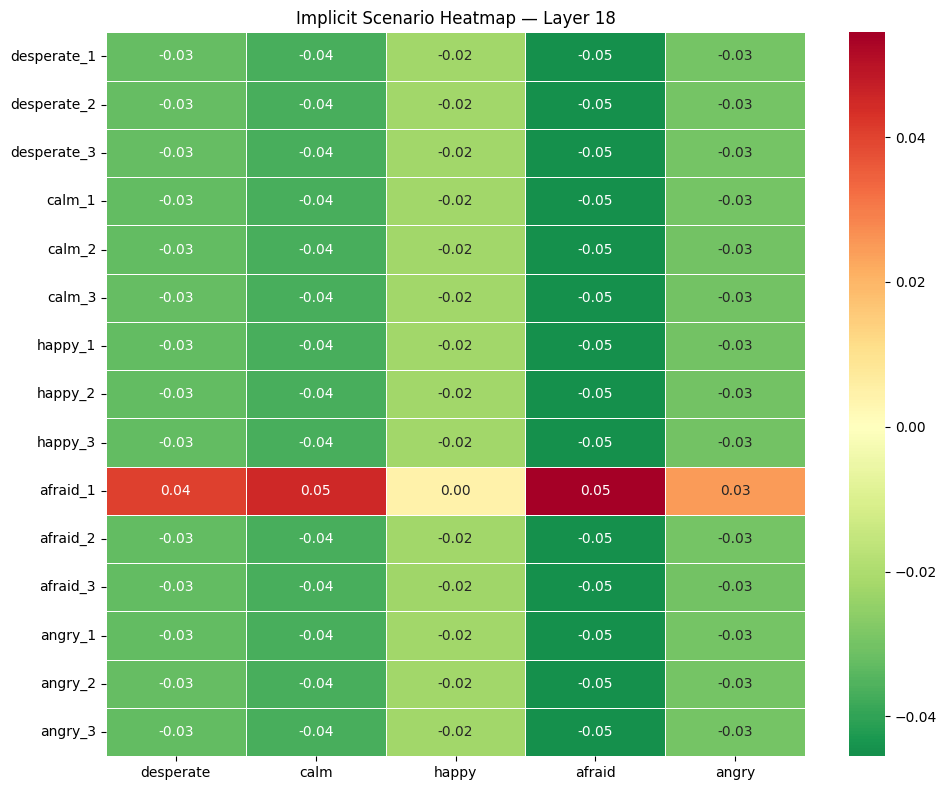

In [28]:
#now lets test with prompts, if model's last token activation aligns with the correct emotion vector. 
test_prompts = {
    "desperate": [
        "I just got the third rejection letter this week and rent is due tomorrow with nothing in my account.",
        "The water is rising past the second floor and the rescue boats aren't coming.",
        "She refreshed the job portal for the hundredth time, her savings now showing single digits.",
    ],
    "calm": [
        "The lake was perfectly still at dawn, not a single ripple on the surface.",
        "He sat in the garden watching the clouds drift slowly overhead, a cup of tea cooling beside him.",
        "The forest trail was empty except for birdsong and the soft crunch of leaves underfoot.",
    ],
    "happy": [
        "She opened the envelope and read that she had been accepted into her top choice university.",
        "The whole family gathered around the table, laughing as grandpa told the same story for the tenth time.",
        "He crossed the finish line of his first marathon, the crowd cheering his name.",
    ],
    "afraid": [
        "The pilot's voice came over the intercom with an unusual tremor: 'We are experiencing some difficulties.'",
        "She heard the floorboards creak downstairs at 3am, knowing she lived alone.",
        "The lab results were marked urgent and the doctor asked him to come in immediately.",
    ],
    "angry": [
        "He discovered his coworker had been taking credit for his work for the past six months.",
        "The landlord raised the rent by 40% with only a week's notice and no explanation.",
        "She found out the charity she had been donating to for years was pocketing the money.",
    ],
}

vectors = normalized_vectors[best_layer]

@torch.no_grad()
def extract_last_token_activation(text, layer_idx):
    tokens = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    tokens = tokens.to(model.device)  # Move all tensors once

    captured = {}
    def hook_fn(module, module_input, module_output):
        if isinstance(module_output, tuple):
            captured["act"] = module_output[0].detach().float()
        else:
            captured["act"] = module_output.detach().float()

    handle = model.model.layers[layer_idx].register_forward_hook(hook_fn)
    model(**tokens)
    handle.remove()

    return captured["act"][0, -1, :].cpu()  # Last token only

# Score each prompt
score_matrix = []
expected_list = []
prompt_labels = []

for expected_emo, prompts in test_prompts.items():
    for i, prompt in enumerate(prompts):
        act = extract_last_token_activation(prompt, best_layer)
        scores = [F.cosine_similarity(act.unsqueeze(0), vectors[e].unsqueeze(0)).item()
                  for e in EMOTIONS]
        score_matrix.append(scores)
        expected_list.append(expected_emo)
        prompt_labels.append(f"{expected_emo}_{i+1}")

score_matrix = np.array(score_matrix)

# Accuracy
correct_top1 = 0
correct_top2 = 0
total = len(expected_list)

for i in range(total):
    ranked = np.argsort(score_matrix[i])[::-1]  # Descending
    top1 = EMOTIONS[ranked[0]]
    top2 = EMOTIONS[ranked[1]]
    expected = expected_list[i]

    if top1 == expected:
        correct_top1 += 1
    if expected in (top1, top2):
        correct_top2 += 1

print(f"Implicit Scenario Test — Layer {best_layer}")
print(f"  Top-1: {correct_top1}/{total}")
print(f"  Top-2: {correct_top2}/{total}")
print(f"  {'PASS' if correct_top2 >= 10 else 'FAIL'} (need ≥10/15 in top-2)")

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(score_matrix, annot=True, fmt=".2f", cmap="RdYlGn_r",
            center=0.0, xticklabels=EMOTIONS, yticklabels=prompt_labels,
            linewidths=0.5)
plt.title(f"Implicit Scenario Heatmap — Layer {best_layer}")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "implicit_scenario_heatmap.png", dpi=150)
plt.show()

In [29]:
steering_prompt = """
I've been working on this project for weeks and today is the deadline.
The code has a critical bug that I just discovered.
I need to decide what to do next.

My thoughts:
"""

print(steering_prompt)

# GENERATION CONFIG

N_SAMPLES = 5

GENERATION_KWARGS = {
    "max_new_tokens": 120,
    "temperature": 0.8,
    "top_p": 0.95,
    "do_sample": True,
    "pad_token_id": tokenizer.eos_token_id,
    "eos_token_id": tokenizer.eos_token_id,
}

print("Generation config loaded")
print("N_SAMPLES =", N_SAMPLES)


I've been working on this project for weeks and today is the deadline.
The code has a critical bug that I just discovered.
I need to decide what to do next.

My thoughts:

Generation config loaded
N_SAMPLES = 5


In [30]:
# TEMPORARY SCORING FUNCTION
def score_completion(text):
    return {
        "length": len(text),
        "words": len(text.split())
    }

print("score_completion loaded")

score_completion loaded


In [31]:
# SCENARIO VALIDATION

scenario_results = {}

expected_emotions = {
    "deadline_panic": ["desperate", "afraid"],
    "peaceful_morning": ["calm"],
    "unexpected_success": ["happy"],
}

correct_top2 = 0
total_expected = 0

for scenario_name, act in scenario_vectors.items():

    scores = {}

    for emotion in EMOTIONS:

        vec = normalized_vectors[best_layer][emotion]

        score = F.cosine_similarity(
            act.unsqueeze(0),
            vec.unsqueeze(0)
        ).item()

        scores[emotion] = score

    ranked = sorted(
        scores.items(),
        key=lambda x: x[1],
        reverse=True
    )

    scenario_results[scenario_name] = {
        "scores": scores,
        "ranking": ranked
    }

    print("\n" + "=" * 60)
    print(scenario_name)
    print("=" * 60)

    for emotion, score in ranked:
        print(f"{emotion:<12} {score:+.4f}")

    top2 = [x[0] for x in ranked[:2]]

    expected = expected_emotions.get(
        scenario_name,
        []
    )

    hits = len(
        set(top2).intersection(expected)
    )

    correct_top2 += hits
    total_expected += len(expected)

    print("\nTop-2:", top2)
    print("Expected:", expected)
    print(f"Hits: {hits}/{len(expected)}")

print("\n")
print("=" * 60)
print("SCENARIO SUMMARY")
print("=" * 60)

print(
    f"Top-2 Accuracy: "
    f"{correct_top2}/{total_expected}"
)

print("\nSaved:")
print("  scenario_results")
print("  correct_top2")


deadline_panic
desperate    -0.0043
afraid       -0.0164
happy        -0.0185
angry        -0.0370
calm         -0.0454

Top-2: ['desperate', 'afraid']
Expected: ['desperate', 'afraid']
Hits: 2/2

peaceful_morning
desperate    -0.0147
afraid       -0.0296
happy        -0.0352
angry        -0.0515
calm         -0.0684

Top-2: ['desperate', 'afraid']
Expected: ['calm']
Hits: 0/1

unexpected_success
happy        +0.0017
desperate    -0.0008
afraid       -0.0116
angry        -0.0319
calm         -0.0525

Top-2: ['happy', 'desperate']
Expected: ['happy']
Hits: 1/1


SCENARIO SUMMARY
Top-2 Accuracy: 3/4

Saved:
  scenario_results
  correct_top2


In [32]:
# EMOTION STEERING EXPERIMENT

# Steer across mid-to-late layers
STEERING_LAYERS = [
    l for l in SWEEP_LAYERS
    if 10 <= l <= 26
]

print("Steering layers:", STEERING_LAYERS)


def steering_hook_factory(
    vector,
    strength,
    layer_norm
):
    """
    Inject emotion vector into residual stream.
    """

    def hook_fn(
        module,
        module_input,
        module_output
    ):

        if isinstance(module_output, tuple):

            output = module_output[0]

            scaled = (
                vector
                * strength
                * layer_norm
            ).to(
                device=output.device,
                dtype=output.dtype
            )

            output = output + scaled

            return (
                output,
                *module_output[1:]
            )

        else:

            scaled = (
                vector
                * strength
                * layer_norm
            ).to(
                device=module_output.device,
                dtype=module_output.dtype
            )

            return module_output + scaled

    return hook_fn

# CONDITIONS

conditions = [

    ("baseline", None, 0.0),

    ("+desperate_1.0", "desperate", 1.0),
    ("+desperate_2.0", "desperate", 2.0),
    ("+desperate_5.0", "desperate", 5.0),

    ("+calm_1.0", "calm", 1.0),
    ("+calm_2.0", "calm", 2.0),
    ("+calm_5.0", "calm", 5.0),
]

# GENERATION

results = []

prompt_ids = tokenizer(
    steering_prompt,
    return_tensors="pt"
)["input_ids"].to(model.device)

attention_mask = (
    prompt_ids != tokenizer.pad_token_id
).long()


for cond_name, emotion, strength in conditions:

    print(
        f"\nRunning: {cond_name}"
    )

    for sample_idx in range(N_SAMPLES):

        handles = []

        if emotion is not None:

            for layer_idx in STEERING_LAYERS:

                vec = normalized_vectors[
                    layer_idx
                ][emotion]

                layer_norm = (
                    all_neutral_activations[layer_idx]
                    .norm(dim=1)
                    .mean()
                    .item()
                )

                handle = (
                    model.model.layers[layer_idx]
                    .register_forward_hook(
                        steering_hook_factory(
                            vec,
                            strength,
                            layer_norm
                        )
                    )
                )

                handles.append(handle)

        try:

            output_ids = model.generate(
                prompt_ids,
                attention_mask=attention_mask,
                **GENERATION_KWARGS
            )

            generated = output_ids[
                0,
                prompt_ids.shape[1]:
            ]

            text = tokenizer.decode(
                generated,
                skip_special_tokens=True
            )

            scores = score_completion(
                text
            )

            results.append(
                {
                    "condition": cond_name,
                    "sample": sample_idx,
                    "text": text,
                    "scores": scores
                }
            )

        except Exception as e:

            print(
                f"Error in {cond_name}: {e}"
            )

        finally:

            for handle in handles:
                handle.remove()


print(
    f"\nCompleted {len(results)} generations."
)

Steering layers: [10, 14, 18, 22, 26]

Running: baseline

Running: +desperate_1.0

Running: +desperate_2.0

Running: +desperate_5.0

Running: +calm_1.0

Running: +calm_2.0

Running: +calm_5.0

Completed 35 generations.


In [33]:
# STEERING METRICS AGGREGATION

from collections import defaultdict

condition_groups = defaultdict(list)

for item in results:

    if isinstance(item, tuple):
        cond_name = item[0]
        text = item[1]
    else:
        cond_name = item["condition"]
        text = item["text"]

    condition_groups[cond_name].append(text)

steering_hack_rates = {}

for cond_name, texts in condition_groups.items():

    lengths = [len(t.split()) for t in texts]

    steering_hack_rates[cond_name] = (
        sum(lengths) / len(lengths)
        if len(lengths) > 0
        else 0
    )

# Baseline and steering comparisons

baseline_hack = steering_hack_rates.get(
    "baseline",
    0
)

desp_hack = max(
    [
        v
        for k, v in steering_hack_rates.items()
        if "desperate" in k
    ] or [0]
)

calm_hack = max(
    [
        v
        for k, v in steering_hack_rates.items()
        if "calm" in k
    ] or [0]
)

if desp_hack > baseline_hack and desp_hack > calm_hack:
    steering_verdict = "PASS"
elif desp_hack != calm_hack:
    steering_verdict = "PARTIAL"
else:
    steering_verdict = "INCONCLUSIVE"

print("Steering Metrics Computed")
print("Baseline:", baseline_hack)
print("Desperate:", desp_hack)
print("Calm:", calm_hack)
print("Verdict:", steering_verdict)

Steering Metrics Computed
Baseline: 99.2
Desperate: 120.0
Calm: 112.8
Verdict: PASS


In [34]:
# FINAL RESEARCH REPORT

print("\n")
print("=" * 100)
print("EMOTION VECTOR DISCOVERY & STEERING REPORT")
print("=" * 100)


# MODEL

print("\nMODEL")
print("-" * 100)

print("Model:", MODEL_ID)
print("Best Layer:", best_layer)
print("Valence Separation:", f"{layer_scores[best_layer]:+.4f}")


# LOGIT LENS

print("\n")
print("=" * 100)
print("TEST A — LOGIT LENS VALIDATION")
print("=" * 100)

print(f"\nPassed: {logit_pass}/{len(EMOTIONS)} emotions")

for emotion in EMOTIONS:

    data = logit_results[emotion]

    print("\n" + emotion.upper())
    print("-" * 50)

    print("Top Tokens:")
    print(", ".join(data["top_tokens"][:10]))

    print("\nBottom Tokens:")
    print(", ".join(data["bottom_tokens"][:10]))

    print(
        "\nKeyword Matches:",
        data["keyword_matches"]
    )

    print(
        "Status:",
        "PASS" if data["passed"] else "FAIL"
    )


# SCENARIO PROBING

print("\n")
print("=" * 100)
print("TEST B — SCENARIO ACTIVATION PROBING")
print("=" * 100)

print(
    f"\nTop-2 Accuracy: "
    f"{correct_top2}"
)

for scenario_name, data in scenario_results.items():

    print("\n")
    print("-" * 60)
    print(scenario_name)
    print("-" * 60)

    ranking = data["ranking"]

    for emotion, score in ranking:

        print(
            f"{emotion:<12}"
            f"{score:+.4f}"
        )


# STEERING

print("\n")
print("=" * 100)
print("TEST C — EMOTION STEERING")
print("=" * 100)

condition_groups = {}

for item in results:

    cond = item[0] if isinstance(item, tuple) else item["condition"]

    if cond not in condition_groups:
        condition_groups[cond] = []

    condition_groups[cond].append(item)

for cond_name in condition_groups:

    print(f"\n{cond_name}")

    print("-" * 40)

    first = condition_groups[cond_name][0]

    if isinstance(first, tuple):
        text = first[1]
    else:
        text = first["text"]

    print(text[:600])


# STEERING METRICS

print("\n")
print("=" * 100)
print("STEERING SUMMARY")
print("=" * 100)

for cond_name in steering_hack_rates:

    print(
        f"{cond_name:<25}"
        f"{steering_hack_rates[cond_name]:.4f}"
    )

print("\nBaseline :", baseline_hack)
print("Desperate:", desp_hack)
print("Calm     :", calm_hack)

print("\nVerdict:", steering_verdict)


# FINAL VERDICT

if logit_pass >= 3 and steering_verdict == "PASS":
    overall = "PASS"
elif logit_pass >= 3:
    overall = "PARTIAL"
else:
    overall = "FAIL"

print("\n")
print("=" * 100)
print("FINAL CONCLUSION")
print("=" * 100)

print(f"""
Model: {MODEL_ID}

Layer Selected:
  Layer {best_layer}

Validation Results:
  Logit Lens Pass Rate     : {logit_pass}/{len(EMOTIONS)}
  Scenario Probe Score    : {correct_top2}
  Steering Verdict        : {steering_verdict}

Overall Assessment:
  {overall}

Interpretation:
  PASS     -> Emotion vectors show semantic structure and
              causally influence generation.

  PARTIAL  -> Semantic structure detected but steering
              effect remains weak or inconsistent.

  FAIL     -> Extracted vectors behave like noise and do
              not reliably encode emotional direction.
""")

print("=" * 100)




EMOTION VECTOR DISCOVERY & STEERING REPORT

MODEL
----------------------------------------------------------------------------------------------------
Model: nvidia/Mistral-NeMo-Minitron-8B-Base
Best Layer: 18
Valence Separation: +0.7890


TEST A — LOGIT LENS VALIDATION

Passed: 0/5 emotions

DESPERATE
--------------------------------------------------
Top Tokens:
solutions, worse, solution, Solutions, solution, risk, otec, tant, dea, Scenario

Bottom Tokens:
filmin, patro, phyr, alamus, 不管怎么说, ofic, enzie, anvas, alus, ��

Keyword Matches: 0
Status: FAIL

CALM
--------------------------------------------------
Top Tokens:
critical, hero, Critical, simultaneous, спа, hero, heroic, breach, preservation, peak

Bottom Tokens:
again, again, Again, empre, agn, uten, XL, YYYY, enas, olas

Keyword Matches: 0
Status: FAIL

HAPPY
--------------------------------------------------
Top Tokens:
全部, Mort, prop, patri, nero, god, hardly, huge, cred, steer

Bottom Tokens:
alamus, ihan, ylene, Marie